# Audit Data — Marketplace Olist Brazilian E-Commerce

**Module :** Traitement de Données  
**Dataset :** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

Ce notebook constitue l'analyse complète d'une marketplace e-commerce brésilienne.
Il est structuré en cinq étapes principales :

- **Étape 1** : compréhension, chargement et exploration des données brutes.
- **Étape 2** : nettoyage table par table, construction des indicateurs intermédiaires et assemblage de la table finale d'analyse.
- **Étape 3** : Construction des indicateurs et analyse globale
- **Étape 4** : Analyses métier approfondies
- **Étape 5** : Synthèse business et recommandations 

Chaque décision de nettoyage est documentée et justifiée. Le code est reproductible :
il suffit de placer les fichiers CSV dans le même dossier que ce notebook et de l'exécuter de haut en bas.

---
# Étape 1 — Compréhension, chargement et exploration des données

Avant de nettoyer ou d'analyser quoi que ce soit, il est indispensable de comprendre
la structure des données disponibles. Cette étape a trois objectifs distincts.

Le premier est de charger l'ensemble des fichiers CSV et d'en vérifier l'intégrité
immédiate : nombre de lignes, nombre de colonnes, types des variables.

Le deuxième est d'identifier les clés primaires de chaque table et les colonnes
qui servent de liens entre elles. Sans cette cartographie, les jointures de l'étape 2
risquent de produire des doublons ou des pertes de données silencieuses.

Le troisième est de construire une première lecture critique des données : quelles
colonnes contiennent des valeurs manquantes ? Quels statuts de commande existent ?
Quelles tables ont plus de lignes que prévu ? Ces observations guideront directement
les décisions de nettoyage.

## 1.1 — Imports des bibliothèques

Les quatre bibliothèques importées ici couvrent l'ensemble des besoins du projet.
`pandas` est la bibliothèque centrale pour charger et manipuler les tableaux de données.
`numpy` fournit les outils de calcul numérique utilisés notamment pour les agrégations.
`matplotlib` et `seaborn` permettront de produire les visualisations des étapes suivantes.

Les deux options d'affichage définies en fin de cellule améliorent la lisibilité
des DataFrames dans le notebook sans modifier les données.

In [38]:
import pandas as pd              # pandas est la bibliothèque principale pour manipuler des tableaux de données (DataFrames)
import numpy as np               # numpy permet de faire des calculs numériques (moyennes, arrondis, etc.)
import matplotlib.pyplot as plt  # matplotlib permet de tracer des graphiques (courbes, barres, histogrammes, etc.)
import seaborn as sns            # seaborn est basé sur matplotlib, mais produit des graphiques plus esthétiques

pd.set_option('display.max_columns', 20)  # autorise l'affichage de jusqu'à 20 colonnes dans un DataFrame (par défaut : 10)
pd.set_option('display.width', 120)       # fixe la largeur d'affichage à 120 caractères pour éviter les coupures de lignes

print('Bibliothèques importées avec succès.')  # message de confirmation que tout s'est bien chargé

Bibliothèques importées avec succès.


## 1.2 — Chargement des fichiers CSV

Le dataset Olist est distribué sous la forme de neuf fichiers CSV distincts.
Chaque fichier correspond à une entité métier de la marketplace : les commandes,
les clients, les articles, les produits, les vendeurs, les paiements, les avis,
la géolocalisation et la table de traduction des catégories.

Tous les fichiers sont chargés dès cette étape afin d'avoir une vue complète
du périmètre de données avant d'entamer toute transformation.

La variable `path` définit le dossier dans lequel se trouvent les fichiers CSV.
Elle est laissée vide si les fichiers sont dans le même dossier que ce notebook.

In [46]:
path = ''  # laisser vide si les CSV sont dans le même dossier que le notebook
           # exemple : path = 'data/' si les fichiers sont dans un sous-dossier 'data'

orders       = pd.read_csv(path + 'olist_orders_dataset.csv')
customers    = pd.read_csv(path + 'olist_customers_dataset.csv')
items        = pd.read_csv(path + 'olist_order_items_dataset.csv')
products     = pd.read_csv(path + 'olist_products_dataset.csv')
sellers      = pd.read_csv(path + 'olist_sellers_dataset.csv')
payments     = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews      = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
geolocation  = pd.read_csv(path + 'olist_geolocation_dataset.csv')
translations = pd.read_csv(path + 'product_category_name_translation.csv')

print('Les 9 fichiers ont été chargés avec succès.')

Les 9 fichiers ont été chargés avec succès.


## 1.3 — Tableau récapitulatif des tables

Avant d'explorer chaque table en détail, il est utile de disposer d'une vue
synthétique de l'ensemble du dataset. Ce tableau indique pour chaque table
son nombre de lignes, son nombre de colonnes et la liste exacte de ses colonnes.

Deux observations méritent d'être notées immédiatement à ce stade.
La table `payments` contient davantage de lignes que `orders`, ce qui signifie
qu'une commande peut avoir plusieurs lignes de paiement.
La table `items` est dans la même situation : une commande peut contenir
plusieurs articles. Ces deux tables devront être agrégées avant toute jointure.

In [47]:
# On regroupe toutes les tables dans un dictionnaire
# clé = nom de la table (str), valeur = le DataFrame correspondant
# Cela permet de les parcourir avec une seule boucle au lieu de répéter le code 9 fois
tables = {
    'orders':       orders,
    'customers':    customers,
    'items':        items,
    'products':     products,
    'sellers':      sellers,
    'payments':     payments,
    'reviews':      reviews,
    'geolocation':  geolocation,
    'translations': translations,
}

recap_rows = []  # liste vide — elle va recevoir un dictionnaire par table à chaque itération de la boucle

for name, df in tables.items():  # .items() retourne des paires (clé, valeur) — ici (nom_table, DataFrame)
    recap_rows.append({          # .append() ajoute un élément à la fin de la liste
        'Table':            name,                           # nom de la table (ex: 'orders')
        'Lignes':           df.shape[0],                    # df.shape retourne un tuple (nb_lignes, nb_colonnes) — [0] = lignes
        'Colonnes':         df.shape[1],                    # [1] = nombre de colonnes
        'Colonnes (liste)': list(df.columns)  # df.columns = Index des noms de colonnes
                                                            # .tolist() convertit l'Index en liste Python ordinaire
                                                            # ', '.join() colle les éléments de la liste avec une virgule
    })

recap = pd.DataFrame(recap_rows)  # pd.DataFrame() transforme la liste de dictionnaires en un seul DataFrame
                                   # chaque dictionnaire de la liste devient une ligne du tableau final
display(recap)                     # display() affiche le DataFrame avec un rendu HTML propre dans Jupyter
                                   # (plus lisible que print() pour les tableaux)

,Table,Lignes,Colonnes,Colonnes (liste)
0,orders,99441,8,"[order_id, customer_id, order_status, order_pu..."
1,customers,99441,5,"[customer_id, customer_unique_id, customer_zip..."
2,items,112650,7,"[order_id, order_item_id, product_id, seller_i..."
3,products,32951,9,"[product_id, product_category_name, product_na..."
4,sellers,3095,4,"[seller_id, seller_zip_code_prefix, seller_cit..."
5,payments,103886,5,"[order_id, payment_sequential, payment_type, p..."
6,reviews,99224,7,"[review_id, order_id, review_score, review_com..."
7,geolocation,1000163,5,"[geolocation_zip_code_prefix, geolocation_lat,..."
8,translations,71,2,"[product_category_name, product_category_name_..."


## 1.4 — Exploration détaillée de chaque table

Pour chaque table, on affiche trois informations complémentaires.

`.info()` révèle les types réels des colonnes tels que pandas les a inférés au chargement.
C'est ici que l'on constate, par exemple, que les colonnes de dates sont lues comme
des chaînes de caractères (`object`) et non comme des `datetime`. Cette information
est directement exploitable à l'étape 2.

`.head(3)` et `.tail(3)` permettent de vérifier visuellement le format des valeurs
et de détecter des anomalies évidentes comme des colonnes mal alignées ou des
encodages incorrects.

`.describe()` est appliqué aux colonnes numériques lorsqu'elles existent.
Il permet de repérer immédiatement des valeurs aberrantes : prix négatifs,
notes hors de l'intervalle attendu, dimensions de produits à zéro.

In [49]:
for name, df in tables.items():
    print('=' * 65)
    print(f'  TABLE : {name.upper()}')
    print(f'  {df.shape[0]:,} lignes  |  {df.shape[1]} colonnes')
    print('=' * 65)

    print('\n--- Types et valeurs manquantes ---')
    df.info()

    print('\n--- Aperçu des premières lignes ---')
    display(df.head(3))

    print('\n--- Aperçu des dernières lignes  ---')
    display(df.tail(3))

    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'\n--- Statistiques descriptives des colonnes numériques (.describe) ---')
        display(df[num_cols].describe().round(2))

    print('\n')

  TABLE : ORDERS
  99,441 lignes  |  8 colonnes

--- Types et valeurs manquantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Aperçu des premières lignes ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- Aperçu des dernières lignes  ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00




  TABLE : CUSTOMERS
  99,441 lignes  |  5 colonnes

--- Types et valeurs manquantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

--- Aperçu des premières lignes ---


...

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1000163.00,1000163.00,1000163.00
mean,36574.17,-21.18,-46.39
std,30549.34,5.72,4.27
min,1001.00,-36.61,-101.47
25%,11075.00,-23.60,-48.57
50%,26530.00,-22.92,-46.64
75%,63504.00,-19.98,-43.77
max,99990.00,45.07,121.11




  TABLE : TRANSLATIONS
  71 lignes  |  2 colonnes

--- Types et valeurs manquantes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB

--- Aperçu des premières lignes ---


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



--- Aperçu des dernières lignes  ---


,product_category_name,product_category_name_english
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services


## 1.5 — Identification des clés primaires et des clés de jointure

Une clé primaire est une colonne dont chaque valeur est unique dans sa table.
Elle identifie sans ambiguïté chaque ligne. Une clé de jointure est une colonne
présente dans deux tables différentes, qui permet de les relier.

La vérification se fait en comparant le nombre de valeurs uniques d'une colonne
au nombre total de lignes de la table. Si les deux sont égaux, la colonne est
bien une clé primaire valide. Dans le cas contraire, cela signifie soit que
la table est naturellement multi-lignes par entité (comme `items` ou `payments`),
soit qu'il existe des doublons à traiter.

Cette vérification est critique : une jointure réalisée sur une colonne
qui n'est pas une vraie clé primaire peut multiplier silencieusement les lignes
et fausser tous les calculs ultérieurs.

In [50]:
# Dictionnaire : nom de table -> colonne supposée être la clé primaire
primary_keys = {
    'orders'      : 'order_id',
    'customers'   : 'customer_id',
    'items'       : None,           # clé composite : (order_id, order_item_id)
    'products'    : 'product_id',
    'sellers'     : 'seller_id',
    'payments'    : None,           # plusieurs lignes par order_id (multi-paiements)
    'reviews'     : 'review_id',
    'geolocation' : None,           # plusieurs coordonnées par code postal
    'translations': 'product_category_name',
}

print(f'{"Table":<15} {"Clé primaire":<30} {"Unique":<10} {"Total lignes":<15} {"Valide ?"}')
print('-' * 80)

for name, df in tables.items():
    col = primary_keys[name]
    if col is None:
        print(f'{name:<15} {"(pas de clé simple)":<30} {"—":<10} {df.shape[0]:<15} —')
    else:
        n_unique = df[col].nunique()
        n_total  = df.shape[0]
        valide   = 'OUI' if n_unique == n_total else f'NON ({n_unique} uniques pour {n_total} lignes)'
        print(f'{name:<15} {col:<30} {n_unique:<10} {n_total:<15} {valide}')

Table           Clé primaire                   Unique     Total lignes    Valide ?
--------------------------------------------------------------------------------
orders          order_id                       99441      99441           OUI
customers       customer_id                    99441      99441           OUI
items           (pas de clé simple)            —          112650          —
products        product_id                     32951      32951           OUI
sellers         seller_id                      3095       3095            OUI
payments        (pas de clé simple)            —          103886          —
reviews         review_id                      98410      99224           NON (98410 uniques pour 99224 lignes)
geolocation     (pas de clé simple)            —          1000163         —
translations    product_category_name          71         71              OUI


## 1.6 — Premières observations critiques sur les colonnes clés

Avant de passer au schéma des relations, il est utile de produire quelques
comptages rapides sur les colonnes catégorielles les plus importantes.

La distribution des statuts de commande dans `orders` est particulièrement
importante : elle déterminera le périmètre exact des analyses. Les commandes
annulées, non livrées ou en cours de traitement ne peuvent pas être incluses
dans des calculs de délai de livraison ou de satisfaction client sans
introduire des biais importants.

La distribution des types de paiement dans `payments` permet de comprendre
les habitudes des clients et d'anticiper les problèmes d'agrégation.

La distribution des notes dans `reviews` donne une première indication
sur la qualité perçue du service avant tout nettoyage.

In [51]:
print('--- Distribution des statuts de commande (orders) ---')
print(orders['order_status'].value_counts())
print()

print('--- Distribution des types de paiement (payments) ---')
print(payments['payment_type'].value_counts())
print()

print('--- Distribution des notes clients (reviews) ---')
print(reviews['review_score'].value_counts().sort_index())
print()

print('--- Valeurs manquantes dans reviews (commentaires) ---')
print(reviews[['review_comment_title', 'review_comment_message']].isnull().sum())
print()

print('--- Nombre de commandes avec plusieurs articles (items) ---')
multi = items.groupby('order_id')['order_item_id'].max()
print(multi.value_counts().head(5))
print()

print('--- Nombre de lignes de paiement par commande (payments) ---')
multi_pay = payments.groupby('order_id')['payment_sequential'].max()
print(multi_pay.value_counts().head(5))

--- Distribution des statuts de commande (orders) ---
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

--- Distribution des types de paiement (payments) ---
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

--- Distribution des notes clients (reviews) ---
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

--- Valeurs manquantes dans reviews (commentaires) ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- Nombre de commandes avec plusieurs articles (items) ---
order_item_id
1    88863
2     7516
3     1322
4      505
5      204
Name: count, dtype: int64

--- Nombre de lignes de paiement par commande (payments) ---
payment_sequential
1    96401
2     2458
3   

## 1.7 — Signification des colonnes principales

On ne peut pas analyser des données sans comprendre ce que chaque colonne représente.
Cette partie décrit les colonnes les plus importantes de chaque table.

---

### `orders` — Commandes

| Colonne | Description |
|---|---|
| `order_id` | Identifiant unique de chaque commande |
| `customer_id` | Lien vers la table customers |
| `order_status` | Statut : delivered, shipped, canceled, etc. |
| `order_purchase_timestamp` | Date et heure d'achat |
| `order_delivered_customer_date` | Date réelle de livraison au client |
| `order_estimated_delivery_date` | Date estimée — utilisée pour calculer les retards |

---

### `customers` — Clients

| Colonne | Description |
|---|---|
| `customer_id` | Identifiant utilisé pour la jointure avec orders |
| `customer_unique_id` | Identifiant réel du client (un client peut avoir plusieurs customer_id) |
| `customer_state` | État brésilien du client (ex: SP, RJ) |
| `customer_zip_code_prefix` | Code postal — lien possible avec geolocation |

---

### `items` — Articles commandés

| Colonne | Description |
|---|---|
| `order_id` | Lien vers la commande |
| `order_item_id` | Numéro de l'article dans la commande (1, 2, 3...) |
| `product_id` | Lien vers le produit |
| `seller_id` | Lien vers le vendeur |
| `price` | Prix de l'article hors livraison |
| `freight_value` | Frais de livraison pour cet article |

---

### `products` — Produits

| Colonne | Description |
|---|---|
| `product_id` | Identifiant unique du produit |
| `product_category_name` | Catégorie en portugais (à traduire via translations) |
| `product_weight_g` | Poids en grammes — utile pour l'analyse logistique |
| `product_length_cm` | Longueur en cm |
| `product_height_cm` | Hauteur en cm |
| `product_width_cm` | Largeur en cm |

---

### `sellers` — Vendeurs

| Colonne | Description |
|---|---|
| `seller_id` | Identifiant unique du vendeur |
| `seller_state` | État du vendeur — pour comparer avec l'état du client |
| `seller_zip_code_prefix` | Code postal vendeur — lien possible avec geolocation |

---

### `payments` — Paiements

| Colonne | Description |
|---|---|
| `order_id` | Lien vers la commande |
| `payment_sequential` | Numéro du paiement (1 = premier paiement) |
| `payment_type` | Moyen de paiement : credit_card, boleto, voucher, debit_card |
| `payment_installments` | Nombre de versements |
| `payment_value` | Montant réellement encaissé pour ce paiement |

---

### `reviews` — Avis clients

| Colonne | Description |
|---|---|
| `review_id` | Identifiant unique de l'avis |
| `order_id` | Lien vers la commande |
| `review_score` | Note client de 1 à 5 |
| `review_comment_message` | Commentaire écrit par le client (souvent vide) |

---

### `geolocation` — Géolocalisation

| Colonne | Description |
|---|---|
| `geolocation_zip_code_prefix` | Code postal (5 chiffres) |
| `geolocation_lat` | Latitude GPS |
| `geolocation_lng` | Longitude GPS |
| `geolocation_state` | État brésilien |

---

### `translations` — Traductions

| Colonne | Description |
|---|---|
| `product_category_name` | Nom de la catégorie en portugais |
| `product_category_name_english` | Traduction en anglais |

## 1.8 — Schéma des relations entre les tables

Le schéma ci-dessous représente les liens entre les neuf tables du dataset.
`orders` est la table centrale : elle est reliée directement à `customers`,
`items`, `payments` et `reviews` via la colonne `order_id` ou `customer_id`.
`items` fait le lien vers `products` et `sellers`.
`geolocation` et `translations` ne possèdent pas de clé étrangère formelle :
elles sont reliées manuellement via `zip_code_prefix` et `product_category_name`.

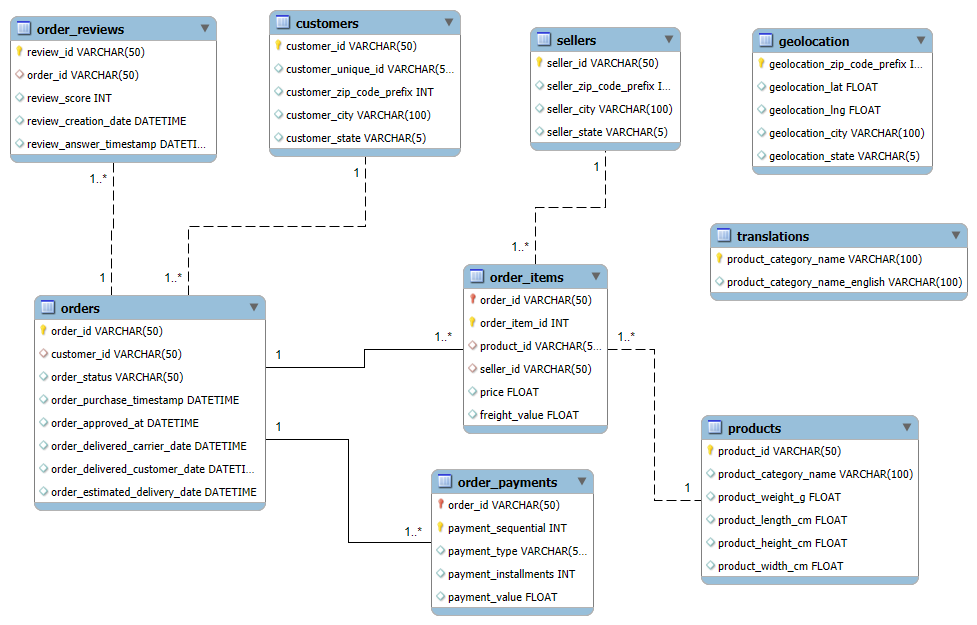

In [53]:
from IPython.display import Image, display  # Image = classe pour charger une image depuis le disque
                                            # display = force l'affichage dans la cellule Jupyter

# Image(filename=...) charge l'image depuis le fichier PNG
# Le fichier schema_relations.png doit être dans le même dossier que ce notebook
display(Image(filename='schema_relations.png'))

### Conclusion — 1.8

La table `orders` est la table centrale du dataset.  
Presque toutes les autres tables se connectent à elle via `order_id`.

Deux tables n'ont pas de lien formel dans le schéma :
- **`geolocation`** : peut être jointe via `zip_code_prefix` (customers ou sellers), mais il faut d'abord l'agréger.
- **`translations`** : jointe via `product_category_name` (products), relation logique mais sans FK déclarée.

La table `items` a une **clé primaire composite** : `order_id + order_item_id`.  
Cela signifie qu'une même commande peut avoir plusieurs lignes dans cette table.

## 1.9 — Justification des tables retenues pour l'analyse finale

Toutes les tables ne jouent pas le même rôle dans l'analyse. Cette section
documente explicitement la décision de retenir ou non chaque table, ainsi
que la raison métier qui justifie ce choix.

Cette justification est importante pour deux raisons. D'une part, elle oblige
à réfléchir à l'utilité réelle de chaque table avant de commencer les jointures.
D'autre part, elle constitue une trace écrite des choix faits, ce qui est
indispensable pour qu'un tiers puisse comprendre et reproduire l'analyse.

In [54]:
justifications = {
    'orders'      : ('Retenue',   'Table centrale du dataset. Elle contient les statuts et toutes les dates clés. Toutes les analyses passent par cette table.'),
    'customers'   : ('Retenue',   'Fournit la localisation géographique des clients. Indispensable pour les analyses par état ou par région.'),
    'items'       : ('Retenue',   'Contient les prix unitaires et les frais de livraison par article. Seule source possible pour calculer le chiffre d affaires réel par produit.'),
    'products'    : ('Retenue',   'Fournit les catégories de produits, le poids et les dimensions. Nécessaire pour les analyses logistiques et par catégorie.'),
    'sellers'     : ('Retenue',   'Fournit la localisation des vendeurs. Permet de comparer la distance entre vendeur et client et d évaluer son impact sur les délais.'),
    'payments'    : ('Retenue',   'Contient les montants réellement encaissés et les modes de paiement. Plus fiable que les prix de la table items pour le montant total payé.'),
    'reviews'     : ('Retenue',   'Mesure directe de la satisfaction client via la note et le commentaire. Colonne principale : review_score.'),
    'translations': ('Retenue',   'Traduit les noms de catégories du portugais vers l anglais. Nécessaire pour produire des graphiques lisibles.'),
    'geolocation' : ('Optionnelle','Contient les coordonnées GPS par code postal. Utile pour calculer des distances réelles. Utilisée si le temps disponible le permet.'),
}

print(f'{"Table":<15}  {"Décision":<12}  Justification')
print('-' * 100)
for table, (decision, raison) in justifications.items():
    print(f'{table:<15}  {decision:<12}  {raison}')

Table            Décision      Justification
----------------------------------------------------------------------------------------------------
orders           Retenue       Table centrale du dataset. Elle contient les statuts et toutes les dates clés. Toutes les analyses passent par cette table.
customers        Retenue       Fournit la localisation géographique des clients. Indispensable pour les analyses par état ou par région.
items            Retenue       Contient les prix unitaires et les frais de livraison par article. Seule source possible pour calculer le chiffre d affaires réel par produit.
products         Retenue       Fournit les catégories de produits, le poids et les dimensions. Nécessaire pour les analyses logistiques et par catégorie.
sellers          Retenue       Fournit la localisation des vendeurs. Permet de comparer la distance entre vendeur et client et d évaluer son impact sur les délais.
payments         Retenue       Contient les montants réellement encais

## 1.9 — Synthèse de l'étape 1

| Tâche | Statut |
|---|---|
| Chargement des 9 fichiers CSV | OK |
| Tableau récapitulatif (lignes, colonnes, types) | OK |
| Exploration détaillée avec .info() et .describe() | OK |
| Identification et vérification des clés primaires | OK |
| Observations critiques sur les colonnes catégorielles | OK |
| Schéma des relations entre les tables | OK |
| Justification des tables retenues | OK |

**Observations importantes transmises à l'étape 2 :**

- Les colonnes de dates sont de type `object` dans toutes les tables. Elles devront être converties en `datetime` avant tout calcul de délai.
- La table `payments` contient plusieurs lignes par commande. Elle devra être agrégée par `order_id` avant la jointure.
- La table `items` est dans la même situation. Elle devra être agrégée selon le même principe.
- La table `geolocation` contient de nombreux doublons par code postal. Une agrégation par médiane sera nécessaire avant toute jointure.
- Les colonnes `review_comment_title` et `review_comment_message` contiennent un grand nombre de valeurs manquantes. Ce comportement est normal : de nombreux clients laissent une note sans rédiger de commentaire.
- 96 478 commandes ont le statut `delivered`. Ce sous-ensemble constituera le périmètre principal de l'analyse.

---
# Étape 2 — Nettoyage, préparation et construction de la table finale

Le nettoyage des données est l'étape la plus critique du projet. Une erreur
commise ici se propagera dans toutes les analyses suivantes sans nécessairement
produire de message d'erreur : les résultats seront simplement faux.

Cette étape est organisée en trois phases distinctes.

La **phase A** applique une routine de nettoyage systématique sur chaque table,
dans l'ordre logique de leur importance métier. Pour chaque table, on vérifie
successivement les doublons, les types des colonnes, les valeurs textuelles,
les colonnes numériques et les valeurs manquantes. Chaque décision est justifiée.

La **phase B** répond aux trois questions difficiles posées par le cahier des
charges : quels types de valeurs manquantes supprimer ou conserver, faut-il
inclure les commandes annulées, et quelles incohérences peuvent fausser les conclusions.

La **phase C** réalise les agrégations nécessaires, puis construit la table
finale par jointures successives. Le nombre de lignes est vérifié après chaque jointure.

---
## Phase A — Nettoyage table par table

La routine appliquée à chaque table suit toujours le même ordre :

1. Création d'une copie de travail pour préserver les données brutes originales.
2. Vérification et suppression des doublons sur la clé primaire.
3. Conversion des colonnes de dates au format `datetime`.
4. Normalisation des colonnes textuelles : suppression des espaces superflus et passage en minuscules.
5. Vérification des colonnes numériques : valeurs négatives, valeurs nulles anormales.
6. Traitement des valeurs manquantes avec justification explicite pour chaque colonne concernée.
7. Affichage du nombre de lignes avant et après nettoyage.

### 2.1 — Nettoyage de la table `orders`

La table `orders` est la table centrale du dataset. Son nettoyage conditionne
la qualité de toutes les analyses ultérieures. Elle contient huit colonnes :
un identifiant de commande, un identifiant client, un statut et cinq colonnes de dates.

Deux points méritent une attention particulière.

Les cinq colonnes de dates ont été chargées comme des chaînes de caractères.
Elles doivent être converties en `datetime` pour permettre les calculs de délais.

La colonne `order_approved_at` contient des valeurs manquantes. Ces absences
sont cohérentes : une commande peut être enregistrée sans avoir encore été
approuvée. On conserve ces lignes plutôt que de les supprimer, car elles seront
de toute façon exclues du périmètre final lors du filtrage sur le statut `delivered`.

In [58]:
df_orders = orders.copy()  # copie de travail — les données brutes restent intactes dans `orders`

print(f'orders avant nettoyage : {orders.shape}')

# -- Doublons sur la clé primaire --
n_dup = df_orders.duplicated(subset='order_id').sum()
print(f'Doublons sur order_id : {n_dup}')
df_orders = df_orders.drop_duplicates(subset='order_id')

# -- Conversion des dates --
date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# -- AJOUT : Détection et suppression des incohérences de dates --
# Anomalie 1 : La livraison client a eu lieu AVANT l'achat
incoh_livraison = df_orders['order_delivered_customer_date'] < df_orders['order_purchase_timestamp']

# Anomalie 2 : La remise au transporteur a eu lieu AVANT l'achat
incoh_transport = df_orders['order_delivered_carrier_date'] < df_orders['order_purchase_timestamp']

# Cumul des incohérences temporelles
incoherences_totatles = incoh_livraison | incoh_transport
n_incoh = incoherences_totatles.sum()

print(f'Incohérences chronologiques détectées (Livraison/Transport < Achat) : {n_incoh}')

if n_incoh > 0:
    # On ne garde que les lignes qui n'ont PAS d'incohérence (le symbole ~ signifie "NOT")
    df_orders = df_orders[~incoherences_totatles]

# -- Textes --
df_orders['order_status'] = df_orders['order_status'].str.strip().str.lower()

# -- Numériques --
# orders ne contient pas de colonnes numériques à vérifier

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_orders :')
print(df_orders.isnull().sum()[df_orders.isnull().sum() > 0])

print(f'\norders après nettoyage  : {df_orders.shape}')
display(df_orders.head(3))

orders avant nettoyage : (99441, 8)
Doublons sur order_id : 0
Incohérences chronologiques détectées (Livraison/Transport < Achat) : 166

Valeurs manquantes dans df_orders :
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2964
dtype: int64

orders après nettoyage  : (99275, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


### 2.2 — Nettoyage de la table `customers`

La table `customers` contient les informations de localisation des clients.
Elle est relativement simple : cinq colonnes, pas de dates, pas de numériques
sensibles. L'attention se porte essentiellement sur les colonnes textuelles
`customer_city` et `customer_state`, qui seront utilisées dans les analyses
géographiques. Une ville écrite "São Paulo" dans une ligne et "sao paulo"
dans une autre serait comptabilisée comme deux entités distinctes.

La distinction entre `customer_id` et `customer_unique_id` est importante.
Un même client physique peut passer plusieurs commandes et apparaître sous
plusieurs `customer_id` distincts. Pour les analyses de fidélité client,
c'est `customer_unique_id` qui devra être utilisé.

In [59]:
df_customers = customers.copy()

print(f'customers avant nettoyage : {customers.shape}')

# -- Doublons --
n_dup = df_customers.duplicated(subset='customer_id').sum()
print(f'Doublons sur customer_id : {n_dup}')
df_customers = df_customers.drop_duplicates(subset='customer_id')

# -- Dates -- aucune colonne de date dans cette table

# -- Textes --
df_customers['customer_city']  = df_customers['customer_city'].str.strip().str.lower()
df_customers['customer_state'] = df_customers['customer_state'].str.strip().str.upper()
# .str.upper() pour customer_state : les codes d'état brésiliens sont des sigles en majuscules (SP, RJ, MG...)

# -- Numériques --
# customer_zip_code_prefix est un code postal — il ne doit pas être traité comme un nombre
# On le convertit en chaîne de caractères pour éviter toute opération arithmétique accidentelle
df_customers['customer_zip_code_prefix'] = df_customers['customer_zip_code_prefix'].astype(str).str.zfill(5)
# .zfill(5) remet les zéros en tête si le code postal a moins de 5 chiffres (ex: '603' -> '00603')

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_customers :')
na = df_customers.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\ncustomers après nettoyage : {df_customers.shape}')

customers avant nettoyage : (99441, 5)
Doublons sur customer_id : 0

Valeurs manquantes dans df_customers :
Aucune valeur manquante.

customers après nettoyage : (99441, 5)


### 2.3 — Nettoyage de la table `items`

La table `items` contient le détail des articles de chaque commande.
C'est la source principale pour calculer le chiffre d'affaires : elle contient
le prix de chaque article et les frais de livraison associés.

Deux points critiques sont à traiter ici.

Premièrement, une même commande peut contenir plusieurs articles, ce qui produit
plusieurs lignes par `order_id`. Cette table ne peut donc pas être jointe
directement à `orders` sans agrégation préalable, au risque de multiplier
les lignes et de fausser tous les totaux.

Deuxièmement, les colonnes `price` et `freight_value` doivent être vérifiées
pour l'absence de valeurs négatives ou nulles. Un prix nul peut indiquer
une erreur de saisie ou un article offert dont il faudrait décider le traitement.

In [60]:
df_items = items.copy()

print(f'items avant nettoyage : {items.shape}')

# -- Doublons --
# La clé primaire de items est composite : (order_id, order_item_id)
# Un doublon réel serait la même commande avec le même numéro d'article deux fois
n_dup = df_items.duplicated(subset=['order_id', 'order_item_id']).sum()
print(f'Doublons sur (order_id, order_item_id) : {n_dup}')
df_items = df_items.drop_duplicates(subset=['order_id', 'order_item_id'])

# -- Dates --
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'], errors='coerce')

# -- Textes -- aucune colonne textuelle métier dans cette table

# -- Numériques --
print(f'\nPrix négatifs ou nuls (price <= 0)       : {(df_items["price"] <= 0).sum()}')
print(f'Frais négatifs ou nuls (freight <= 0)    : {(df_items["freight_value"] <= 0).sum()}')
# Les frais de livraison peuvent légitimement être à 0 (livraison offerte)
# On conserve ces lignes mais on les signale

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_items :')
na = df_items.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\nitems après nettoyage : {df_items.shape}')

items avant nettoyage : (112650, 7)
Doublons sur (order_id, order_item_id) : 0

Prix négatifs ou nuls (price <= 0)       : 0
Frais négatifs ou nuls (freight <= 0)    : 383

Valeurs manquantes dans df_items :
Aucune valeur manquante.

items après nettoyage : (112650, 7)


### 2.4 — Nettoyage de la table `products`

La table `products` décrit les caractéristiques physiques et catégorielles
des produits vendus sur la plateforme. Elle contient neuf colonnes : un identifiant,
une catégorie en portugais, des métadonnées textuelles (longueur du nom, longueur
de la description, nombre de photos) et quatre dimensions physiques (poids, longueur,
hauteur, largeur).

Les colonnes `product_name_lenght` et `product_description_lenght` contiennent
une faute de frappe dans leur nom original (`lenght` au lieu de `length`).
On ne renomme pas ces colonnes ici pour rester fidèle au dataset source,
mais on le signale.

Les valeurs manquantes dans `product_category_name` posent un problème métier
concret : sans catégorie, ces produits ne pourront pas être inclus dans les
analyses par catégorie. On remplace ces valeurs manquantes par la chaîne
`'desconhecido'` (inconnu en portugais) pour les conserver dans les analyses
de volume tout en les identifiant clairement.

Les dimensions physiques (poids, longueur, hauteur, largeur) peuvent également
être manquantes. Ces colonnes sont utiles pour les analyses logistiques mais
pas indispensables pour les analyses financières. On conserve ces lignes
avec leurs valeurs manquantes et on les exclura uniquement des analyses
qui requièrent ces dimensions.

In [61]:
df_products = products.copy()

print(f'products avant nettoyage : {products.shape}')

# -- Doublons --
n_dup = df_products.duplicated(subset='product_id').sum()
print(f'Doublons sur product_id : {n_dup}')
df_products = df_products.drop_duplicates(subset='product_id')

# -- Dates -- aucune colonne de date dans cette table

# -- Textes --
df_products['product_category_name'] = (
    df_products['product_category_name']
    .str.strip()
    .str.lower()
    .fillna('desconhecido')  # remplace les NaN par 'desconhecido' pour conserver ces produits dans les analyses de volume
)

# -- Numériques --
dims = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dims:
    n_neg = (df_products[col] < 0).sum()
    if n_neg > 0:
        print(f'Valeurs négatives dans {col} : {n_neg} -> supprimées')
        df_products = df_products[df_products[col] >= 0]
    # Les valeurs nulles (0) sont théoriquement impossibles pour des dimensions physiques
    # mais on les conserve plutôt que de les supprimer sans vérification supplémentaire

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_products après remplacement de la catégorie :')
na = df_products.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')
# Les NaN restants sur les dimensions sont conservés intentionnellement

print(f'\nproducts après nettoyage : {df_products.shape}')

products avant nettoyage : (32951, 9)
Doublons sur product_id : 0

Valeurs manquantes dans df_products après remplacement de la catégorie :
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

products après nettoyage : (32951, 9)


### 2.5 — Nettoyage de la table `sellers`

La table `sellers` contient les informations de localisation des vendeurs.
Sa structure est identique à celle de `customers` : un identifiant, un code
postal, une ville et un état. Le même traitement est donc appliqué.

Cette table sera utilisée pour comparer la localisation des vendeurs avec
celle des clients, afin d'évaluer l'influence de la distance géographique
sur les délais de livraison et la satisfaction client.

In [62]:
df_sellers = sellers.copy()

print(f'sellers avant nettoyage : {sellers.shape}')

# -- Doublons --
n_dup = df_sellers.duplicated(subset='seller_id').sum()
print(f'Doublons sur seller_id : {n_dup}')
df_sellers = df_sellers.drop_duplicates(subset='seller_id')

# -- Textes --
df_sellers['seller_city']  = df_sellers['seller_city'].str.strip().str.lower()
df_sellers['seller_state'] = df_sellers['seller_state'].str.strip().str.upper()

# -- Numériques --
df_sellers['seller_zip_code_prefix'] = df_sellers['seller_zip_code_prefix'].astype(str).str.zfill(5)

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_sellers :')
na = df_sellers.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\nsellers après nettoyage : {df_sellers.shape}')

sellers avant nettoyage : (3095, 4)
Doublons sur seller_id : 0

Valeurs manquantes dans df_sellers :
Aucune valeur manquante.

sellers après nettoyage : (3095, 4)


### 2.6 — Nettoyage de la table `payments`

La table `payments` enregistre les transactions financières associées à chaque commande.
Une commande peut donner lieu à plusieurs lignes de paiement, par exemple si le client
règle une partie en carte de crédit et une autre en bon de réduction. C'est pourquoi
cette table contient davantage de lignes que la table `orders`.

La colonne `payment_value` doit être vérifiée pour l'absence de valeurs négatives
ou nulles. Une valeur nulle est techniquement possible dans le cas de commandes
entièrement réglées par un bon de réduction, mais une valeur négative serait
une anomalie à supprimer.

La colonne `payment_type` contient une valeur connue du dataset Olist :
`'not_defined'`. Cette valeur correspond à des cas où le mode de paiement
n'a pas pu être enregistré. On conserve ces lignes car le montant reste valide,
mais on les signale.

In [63]:
df_payments = payments.copy()

print(f'payments avant nettoyage : {payments.shape}')

# -- Doublons --
# La clé primaire est composite : (order_id, payment_sequential)
n_dup = df_payments.duplicated(subset=['order_id', 'payment_sequential']).sum()
print(f'Doublons sur (order_id, payment_sequential) : {n_dup}')
df_payments = df_payments.drop_duplicates(subset=['order_id', 'payment_sequential'])

# -- Textes --
df_payments['payment_type'] = df_payments['payment_type'].str.strip().str.lower()

# -- Numériques --
print(f'\nValeurs négatives dans payment_value : {(df_payments["payment_value"] < 0).sum()}')
df_payments = df_payments[df_payments['payment_value'] >= 0]
# On supprime les valeurs négatives car elles sont incohérentes avec la réalité d'un paiement

print(f'Lignes avec payment_type = not_defined : {(df_payments["payment_type"] == "not_defined").sum()}')
# Conservées : le montant est valide, seul le mode de paiement est inconnu

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_payments :')
na = df_payments.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\npayments après nettoyage : {df_payments.shape}')

payments avant nettoyage : (103886, 5)
Doublons sur (order_id, payment_sequential) : 0

Valeurs négatives dans payment_value : 0
Lignes avec payment_type = not_defined : 3

Valeurs manquantes dans df_payments :
Aucune valeur manquante.

payments après nettoyage : (103886, 5)


### 2.7 — Nettoyage de la table `reviews`

La table `reviews` est la mesure directe de la satisfaction client.
Elle contient la note attribuée par le client (`review_score`), un titre
et un commentaire optionnels, ainsi que deux colonnes de dates.

Trois points méritent une attention particulière.

La colonne `review_score` doit contenir uniquement des entiers compris entre 1 et 5.
Toute valeur hors de cet intervalle est une anomalie à supprimer.

Les colonnes `review_comment_title` et `review_comment_message` sont très
majoritairement vides. Cette absence est normale : la plupart des clients
laissent une note sans rédiger de commentaire. On conserve ces lignes car
la note est présente. Ces colonnes textuelles ne seront pas utilisées dans
les analyses quantitatives.

La table `reviews` peut contenir plusieurs avis pour une même commande
dans de rares cas. On conservera uniquement le dernier avis déposé,
identifié par la date `review_answer_timestamp` la plus récente.

In [64]:
df_reviews = reviews.copy()

print(f'reviews avant nettoyage : {reviews.shape}')

# -- Doublons sur review_id --
n_dup = df_reviews.duplicated(subset='review_id').sum()
print(f'Doublons sur review_id : {n_dup}')
df_reviews = df_reviews.drop_duplicates(subset='review_id')

# -- Dates --
df_reviews['review_creation_date']    = pd.to_datetime(df_reviews['review_creation_date'],    errors='coerce')
df_reviews['review_answer_timestamp'] = pd.to_datetime(df_reviews['review_answer_timestamp'], errors='coerce')

# -- Numériques : review_score doit être dans [1, 5] --
hors_intervalle = df_reviews[~df_reviews['review_score'].between(1, 5)].shape[0]
print(f'Notes hors intervalle [1, 5] : {hors_intervalle} -> supprimées')
df_reviews = df_reviews[df_reviews['review_score'].between(1, 5)]

# -- Plusieurs avis par commande : on garde le plus récent --
n_avant = df_reviews.shape[0]
df_reviews = (
    df_reviews
    .sort_values('review_answer_timestamp', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
    # keep='first' conserve la ligne avec la date la plus récente après le tri décroissant
)
print(f'Lignes supprimées (avis multiples par commande) : {n_avant - df_reviews.shape[0]}')

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_reviews :')
na = df_reviews.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')
# review_comment_title et review_comment_message sont vides pour la majorité des lignes
# Ce comportement est normal et documenté dans la description du dataset

print(f'\nreviews après nettoyage : {df_reviews.shape}')

reviews avant nettoyage : (99224, 7)
Doublons sur review_id : 814
Notes hors intervalle [1, 5] : 0 -> supprimées
Lignes supprimées (avis multiples par commande) : 243

Valeurs manquantes dans df_reviews :
review_comment_title      86654
review_comment_message    57592
dtype: int64

reviews après nettoyage : (98167, 7)


### 2.8 — Nettoyage de la table `translations`

La table `translations` est une petite table de référence qui associe chaque
nom de catégorie en portugais à sa traduction en anglais. Elle contient 71 lignes
et deux colonnes.

Son nettoyage est minimal, mais il est important de s'assurer que les noms
de catégories sont écrits de manière identique dans `products` et dans `translations`,
car la jointure entre ces deux tables repose sur une correspondance exacte
de chaînes de caractères. Toute différence de casse ou d'espace produira
des valeurs manquantes après jointure.

In [65]:
df_translations = translations.copy()

print(f'translations avant nettoyage : {translations.shape}')

# -- Doublons --
n_dup = df_translations.duplicated(subset='product_category_name').sum()
print(f'Doublons sur product_category_name : {n_dup}')
df_translations = df_translations.drop_duplicates(subset='product_category_name')

# -- Textes : normalisation stricte pour garantir la correspondance avec df_products --
df_translations['product_category_name']         = df_translations['product_category_name'].str.strip().str.lower()
df_translations['product_category_name_english'] = df_translations['product_category_name_english'].str.strip().str.lower()

# -- Valeurs manquantes --
print('\nValeurs manquantes dans df_translations :')
na = df_translations.isnull().sum()
print(na[na > 0] if na[na > 0].shape[0] > 0 else 'Aucune valeur manquante.')

print(f'\ntranslations après nettoyage : {df_translations.shape}')

translations avant nettoyage : (71, 2)
Doublons sur product_category_name : 0

Valeurs manquantes dans df_translations :
Aucune valeur manquante.

translations après nettoyage : (71, 2)


---
## Phase B — Réponses aux trois questions difficiles

Le cahier des charges pose trois questions qui ne se résolvent pas par du code seul.
Elles exigent un raisonnement métier explicite avant de prendre une décision technique.
Cette phase documente ces trois décisions de manière claire et argumentée.

### 2.9 — Question 1 : quels types de valeurs manquantes supprimer, conserver ou remplacer ?

La réponse dépend du rôle de chaque colonne dans les analyses prévues.

**Valeurs manquantes conservées sans remplacement :**
`order_approved_at`, `order_delivered_carrier_date` et `order_delivered_customer_date`
sont manquantes uniquement pour les commandes non encore livrées. Ces lignes seront
naturellement exclues lors du filtrage sur le statut `delivered` en phase C.
Les supprimer dès maintenant serait prématuré et réduirait inutilement le périmètre.

`review_comment_title` et `review_comment_message` sont vides pour la majorité
des clients. L'absence de commentaire est un comportement normal, pas une anomalie.
Ces colonnes ne sont pas utilisées dans les analyses quantitatives.

Les dimensions physiques (`product_weight_g`, `product_length_cm`, etc.) sont
manquantes pour un très faible nombre de produits. On les conserve et on les
exclura uniquement des analyses logistiques qui requièrent ces variables.

**Valeurs manquantes remplacées :**
`product_category_name` a été remplacée par `'desconhecido'` pour conserver
ces produits dans les analyses de volume sans les confondre avec une catégorie réelle.

**Valeurs manquantes qui entraîneront une exclusion à la jointure :**
Les 646 commandes sans `review_score` seront présentes dans la table finale
avec un NaN sur cette colonne. Elles seront exclues uniquement des analyses
de satisfaction, pas des analyses financières ou logistiques.


| Colonne | Décision | Justification |
|---|---|---|
| `order_delivered_customer_date` vide | **Conserver** | Commande non livrée — information utile, pas une erreur |
| `order_approved_at` vide | **Conserver** | Commande non approuvée — cas rares, on note |
| `review_comment_message` vide | **Conserver** | Client a noté sans commenter — colonne non critique |
| `review_score` vide | **Supprimer** | Sans note, la ligne est inutilisable pour la satisfaction |
| `product_category_name` vide | **Remplacer par "desconhecido"** | On garde le produit dans l'analyse |
| `product_weight_g` vide | **Conserver vide** | Utile pour la logistique mais pas critique pour le CA |
| Incohérences de dates | **Supprimer** | Des dates impossibles fausseraient tous les calculs de délais |

### 2.10 — Question 2 : les commandes annulées doivent-elles être incluses dans toutes les analyses ?

Non. Les commandes annulées doivent être exclues de la grande majorité des analyses,
et ce choix doit être appliqué de manière cohérente dès la construction de la table finale.

Voici le raisonnement. Une commande annulée n'a pas été livrée. Elle ne possède donc
pas de date de livraison réelle, ce qui rend impossible le calcul d'un délai
ou d'un retard. L'inclure dans ces calculs produirait soit des erreurs, soit des
valeurs manquantes qui biaiseraient les statistiques.

De plus, une commande annulée n'a généralement pas donné lieu à un paiement
effectif ni à un avis client représentatif. L'inclure dans le chiffre d'affaires
ou dans l'analyse de satisfaction introduirait des biais importants.

La décision retenue est de construire la table finale uniquement à partir des
commandes ayant le statut `delivered`. Ce sous-ensemble représente 96 478 commandes
sur 99 441, soit environ 97 % du dataset. Les commandes annulées pourront
faire l'objet d'une analyse séparée et ciblée si nécessaire.

### 2.11 — Question 3 : quelles incohérences importantes peuvent fausser les conclusions finales ?

Trois types d'incohérences ont été identifiés dans ce dataset.

**Incohérence de dates :** il est possible que certaines commandes affichent une date
de livraison réelle antérieure à la date d'achat, ce qui est physiquement impossible.
Ces lignes seront détectées et supprimées en phase C, après la jointure.

**Incohérence de volume entre tables :** `payments` et `items` contiennent plus de lignes
que `orders`. Si l'on joint ces tables sans agrégation préalable, chaque commande
multi-articles ou multi-paiements génèrera plusieurs lignes dans la table finale,
multipliant artificiellement le chiffre d'affaires calculé. L'agrégation préalable
en phase C est la réponse à cette incohérence.

**Incohérence dans `review_score` :** des notes hors de l'intervalle [1, 5] ont été
supprimées en phase A. Les conserver aurait faussé toutes les moyennes de satisfaction.

---
## Phase C — Agrégations, jointures et construction de la table finale

La table finale est construite en plusieurs étapes successives.
On commence par agréger les tables qui ont plusieurs lignes par commande,
puis on réalise les jointures dans un ordre logique en partant de `orders`.

Le nombre de lignes est affiché avant et après chaque jointure.
Une augmentation inattendue du nombre de lignes signale un problème
dans la clé de jointure utilisée et doit être investiguée immédiatement.

### 2.12 — Agrégation de la table `items`

Chaque commande peut contenir plusieurs articles. On agrège `df_items` par `order_id`
pour obtenir une ligne unique par commande, avec le chiffre d'affaires total
(somme des prix), les frais de livraison totaux, le nombre d'articles,
et le `seller_id` principal (le vendeur du premier article, `order_item_id == 1`).

On récupère également le `product_id` principal de la même façon, pour pouvoir
rejoindre ensuite la table `products` et récupérer la catégorie du produit principal.

In [66]:
# Agrégation financière par commande
items_agg = df_items.groupby('order_id').agg(
    chiffre_affaires      = ('price',         'sum'),   # somme des prix de tous les articles
    frais_livraison_total = ('freight_value', 'sum'),   # somme des frais de livraison
    nb_articles           = ('order_item_id', 'max'),   # order_item_id max = nombre d'articles
).reset_index()

# Récupération du seller_id et du product_id principaux (premier article)
items_principal = (
    df_items[df_items['order_item_id'] == 1][['order_id', 'seller_id', 'product_id']]
)

items_agg = items_agg.merge(items_principal, on='order_id', how='left')

print(f'items agrégé : {items_agg.shape}')
print(f'Nombre de order_id uniques dans df_items : {df_items["order_id"].nunique()}')
# Ces deux nombres doivent être égaux

items agrégé : (98666, 6)
Nombre de order_id uniques dans df_items : 98666


### 2.13 — Agrégation de la table `payments`

De même, `df_payments` est agrégée par `order_id` pour obtenir le montant total
payé, le nombre de lignes de paiement et le mode de paiement principal
(celui correspondant au `payment_sequential` égal à 1, c'est-à-dire le premier
et généralement le principal mode de règlement).

In [67]:
# Agrégation financière par commande
payments_agg = df_payments.groupby('order_id').agg(
    montant_total_paye = ('payment_value',        'sum'),
    nb_paiements       = ('payment_sequential',   'max'),
).reset_index()

# Mode de paiement principal : le premier enregistrement (payment_sequential == 1)
payments_principal = (
    df_payments[df_payments['payment_sequential'] == 1][['order_id', 'payment_type']]
    .rename(columns={'payment_type': 'mode_paiement_principal'})
)

payments_agg = payments_agg.merge(payments_principal, on='order_id', how='left')

print(f'payments agrégé : {payments_agg.shape}')
print(f'Nombre de order_id uniques dans df_payments : {df_payments["order_id"].nunique()}')

payments agrégé : (99440, 4)
Nombre de order_id uniques dans df_payments : 99440


### 2.14 — Enrichissement de la table `products` avec les traductions

Avant de joindre `products` à la table finale, on lui ajoute les noms de catégories
en anglais via une jointure avec `df_translations`. Cette jointure est réalisée
ici, au niveau de la table source, plutôt que dans la chaîne de jointures principale,
pour garder celle-ci lisible.

On utilise un `left join` pour conserver tous les produits, y compris ceux dont
la catégorie n'a pas de traduction disponible. Dans ce cas, `product_category_name_english`
sera NaN, ce qui est préférable à une perte silencieuse de lignes.

In [68]:
n_avant = df_products.shape[0]

df_products_enrichi = df_products.merge(
    df_translations[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left',  # on conserve tous les produits, même sans traduction
)

print(f'products avant enrichissement : {n_avant}')
print(f'products après enrichissement : {df_products_enrichi.shape[0]}')
print(f'Catégories sans traduction    : {df_products_enrichi["product_category_name_english"].isnull().sum()}')

products avant enrichissement : 32951
products après enrichissement : 32951
Catégories sans traduction    : 623


### 2.15 — Construction de la table finale par jointures successives

La table finale est construite en partant de `df_orders` filtrée sur le statut
`delivered`, puis en ajoutant successivement les informations de chaque table.

L'ordre des jointures suit la logique métier : on commence par les tables
qui apportent des informations sur la commande elle-même (clients, articles,
paiements, avis), puis on enrichit avec les informations sur les entités
référencées (vendeurs, produits).

Chaque jointure utilise un `left join` pour conserver toutes les commandes
de référence, même si une table secondaire ne contient pas de correspondance.
Le nombre de lignes est vérifié après chaque jointure : il doit rester
strictement identique à celui de la table de gauche, puisque les tables
secondaires ont été agrégées au niveau `order_id`.

In [69]:
# -- Point de départ : commandes livrées uniquement --
df_final = df_orders[df_orders['order_status'] == 'delivered'].copy()
print(f'Départ (delivered uniquement)     : {df_final.shape[0]:>7,} lignes')

# -- Jointure 1 : informations clients --
df_final = df_final.merge(
    df_customers[['customer_id', 'customer_unique_id',
                  'customer_zip_code_prefix', 'customer_city', 'customer_state']],
    on='customer_id', how='left'
)
print(f'Après jointure customers          : {df_final.shape[0]:>7,} lignes')

# -- Jointure 2 : articles agrégés --
df_final = df_final.merge(items_agg, on='order_id', how='left')
print(f'Après jointure items_agg          : {df_final.shape[0]:>7,} lignes')

# -- Jointure 3 : paiements agrégés --
df_final = df_final.merge(payments_agg, on='order_id', how='left')
print(f'Après jointure payments_agg       : {df_final.shape[0]:>7,} lignes')

# -- Jointure 4 : avis clients --
df_final = df_final.merge(
    df_reviews[['order_id', 'review_score', 'review_id']],
    on='order_id', how='left'
)
print(f'Après jointure reviews            : {df_final.shape[0]:>7,} lignes')

# -- Jointure 5 : informations vendeurs --
df_final = df_final.merge(
    df_sellers[['seller_id', 'seller_city', 'seller_state', 'seller_zip_code_prefix']],
    on='seller_id', how='left'
)
print(f'Après jointure sellers            : {df_final.shape[0]:>7,} lignes')

# -- Jointure 6 : informations produits enrichies --
df_final = df_final.merge(
    df_products_enrichi[[
        'product_id', 'product_category_name_english',
        'product_weight_g', 'product_length_cm',
        'product_height_cm', 'product_width_cm'
    ]],
    on='product_id', how='left'
)
print(f'Après jointure products           : {df_final.shape[0]:>7,} lignes')

Départ (delivered uniquement)     :  96,313 lignes
Après jointure customers          :  96,313 lignes
Après jointure items_agg          :  96,313 lignes
Après jointure payments_agg       :  96,313 lignes
Après jointure reviews            :  96,313 lignes
Après jointure sellers            :  96,313 lignes
Après jointure products           :  96,313 lignes


### 2.16 — Suppression des incohérences de dates

Une fois la table finale assemblée, on peut vérifier les incohérences de dates
qui n'étaient pas détectables dans les tables individuelles.

Deux incohérences sont vérifiées ici. La première concerne les commandes dont
la date de livraison réelle est antérieure à la date d'achat, ce qui est
physiquement impossible. La seconde concerne les commandes dont la date de livraison
réelle est antérieure à la date d'approbation, ce qui est également incohérent.

Ces lignes représentent des erreurs de saisie et sont supprimées.

In [70]:
n_avant = df_final.shape[0]

# Incohérence 1 : livraison avant achat
mask_1 = df_final['order_delivered_customer_date'] < df_final['order_purchase_timestamp']
print(f'Livraison avant achat     : {mask_1.sum()} lignes -> supprimées')

# Incohérence 2 : livraison avant approbation
mask_2 = df_final['order_delivered_customer_date'] < df_final['order_approved_at']
print(f'Livraison avant approbation : {mask_2.sum()} lignes -> supprimées')

df_final = df_final[~mask_1 & ~mask_2]

print(f'\nLignes supprimées pour incohérence de dates : {n_avant - df_final.shape[0]}')
print(f'Table finale après suppression des incohérences : {df_final.shape[0]:,} lignes')

Livraison avant achat     : 0 lignes -> supprimées
Livraison avant approbation : 61 lignes -> supprimées

Lignes supprimées pour incohérence de dates : 61
Table finale après suppression des incohérences : 96,252 lignes


### 2.17 — Vérification finale et export

Avant d'exporter la table finale, on vérifie son contenu global : nombre de lignes,
nombre de colonnes, liste complète des colonnes disponibles, et valeurs manquantes
résiduelles colonne par colonne.

Les valeurs manquantes résiduelles ne sont pas des erreurs. Elles correspondent
à des situations documentées et assumées : commandes sans avis, produits sans
traduction de catégorie, ou commandes sans informations de transport.
Chaque analyse ultérieure devra exclure les lignes concernées uniquement
sur les colonnes qu'elle utilise.

In [72]:
print('=' * 55)
print('  TABLE FINALE — df_final')
print('=' * 55)
print(f'  Lignes   : {df_final.shape[0]:,}')
print(f'  Colonnes : {df_final.shape[1]}')
print()
print('  Colonnes disponibles :')
for col in df_final.columns:
    print(f'    - {col}')
display (df_final.head(3))
print()
print('  Valeurs manquantes résiduelles :')
na_final = df_final.isnull().sum()
display(na_final[na_final > 0].to_frame('Manquants'))

  TABLE FINALE — df_final
  Lignes   : 96,252
  Colonnes : 30

  Colonnes disponibles :
    - order_id
    - customer_id
    - order_status
    - order_purchase_timestamp
    - order_approved_at
    - order_delivered_carrier_date
    - order_delivered_customer_date
    - order_estimated_delivery_date
    - customer_unique_id
    - customer_zip_code_prefix
    - customer_city
    - customer_state
    - chiffre_affaires
    - frais_livraison_total
    - nb_articles
    - seller_id
    - product_id
    - montant_total_paye
    - nb_paiements
    - mode_paiement_principal
    - review_score
    - review_id
    - seller_city
    - seller_state
    - seller_zip_code_prefix
    - product_category_name_english
    - product_weight_g
    - product_length_cm
    - product_height_cm
    - product_width_cm


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_id,seller_city,seller_state,seller_zip_code_prefix,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,03149,...,4.0,a54f0611adc9ed256b57ede6b6eb5114,maua,SP,09350,housewares,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,4.0,8d5266042046a06655c8db133d120ba5,belo horizonte,SP,31570,perfumery,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5.0,e73b67b67587f7644d5bd1a52deb1b01,guariba,SP,14840,auto,420.0,24.0,19.0,21.0



  Valeurs manquantes résiduelles :


,Manquants
order_approved_at,14
order_delivered_carrier_date,2
order_delivered_customer_date,8
montant_total_paye,1
nb_paiements,1
mode_paiement_principal,78
review_score,1102
review_id,1102
product_category_name_english,1377
product_weight_g,16


In [73]:
df_final.to_csv('df_final.csv', index=False)

print(f'Table finale exportée : df_final.csv')
print(f'  {df_final.shape[0]:,} lignes x {df_final.shape[1]} colonnes')

Table finale exportée : df_final.csv
  96,252 lignes x 30 colonnes


## 2.18 — Synthèse de l'étape 2

| Tâche | Statut |
|---|---|
| Nettoyage de orders : dates, textes, doublons | OK |
| Nettoyage de customers : textes, code postal | OK |
| Nettoyage de items : doublons composites, numériques, dates | OK |
| Nettoyage de products : catégorie manquante, dimensions négatives | OK |
| Nettoyage de sellers : textes, code postal | OK |
| Nettoyage de payments : numériques négatifs, textes | OK |
| Nettoyage de reviews : score hors [1,5], avis multiples | OK |
| Nettoyage de translations : doublons, normalisation texte | OK |
| Trois questions difficiles documentées | OK |
| Agrégation de items par order_id | OK |
| Agrégation de payments par order_id | OK |
| Enrichissement de products avec translations | OK |
| Six jointures avec vérification du nombre de lignes | OK |
| Suppression des incohérences de dates | OK |
| Valeurs manquantes résiduelles documentées | OK |
| Table finale exportée en df_final.csv | OK |

**La table finale est prête pour l'étape 3 : construction des indicateurs et analyse globale.**